In [2]:
import numpy as np
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
import scipy.signal
import pynapple as nap

import pandas as pd
import scipy.io as spio
import os

from totalsync_utils import decode_b64_files
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "figure.figsize": (8, 4)}
sns.set_context("paper")
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.3, rc=custom_params)



In [3]:
pin_sheet_file = '/Users/fpbattaglia/src/ofl_2p_analysis/docs/pinSheet.json'
Path_non_decoded_files = "/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116"
s3d_results_folder = "/Users/fpbattaglia/Dropbox/Data/ofl_2p/s3d-results-00003split_test-std"


In [4]:
b64_files = sorted(Path(Path_non_decoded_files).glob("*.b64"))
b64_files = sorted(str(p) for p in Path(Path_non_decoded_files).glob("*.b64"))
tsync_file = b64_files[2]
tsync_session = Path(tsync_file).stem

results_pins = decode_b64_files(Path_non_decoded_files, pin_json_path=pin_sheet_file)

tsync_data = results_pins[tsync_session]


Processing 20251118-155459_534.b64...
/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-155459_534.b64
624348 packets, ~10.41 minutes


100%|██████████| 624348/624348 [00:06<00:00, 89400.43it/s]



Processing 20251120-122334_670.b64...
/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251120-122334_670.b64
2139534 packets, ~35.66 minutes


100%|██████████| 2139534/2139534 [00:24<00:00, 88971.68it/s]



Processing 20251118-155315_863.b64...
/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-155315_863.b64
83025 packets, ~1.38 minutes


100%|██████████| 83025/83025 [00:00<00:00, 88115.61it/s]



Processing 20251118-152602_925.b64...
/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-152602_925.b64
1383156 packets, ~23.05 minutes


100%|██████████| 1383156/1383156 [00:15<00:00, 86878.37it/s]



Processing 20251118-160736_363.b64...
/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-160736_363.b64
789669 packets, ~13.16 minutes


100%|██████████| 789669/789669 [00:08<00:00, 88424.44it/s]


In [5]:
## testing 00001

tsync_file = b64_files[0]
tsync_session = Path(tsync_file).stem
tsync_data_00001 = results_pins[tsync_session]

In [6]:
b64_files

['/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-152602_925.b64',
 '/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-155315_863.b64',
 '/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-155459_534.b64',
 '/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251118-160736_363.b64',
 '/Users/fpbattaglia/Dropbox/Data/ofl_2p/Totalsync/477116/20251120-122334_670.b64']

In [7]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) == 1)[0]+1

In [8]:
def fix_tsync_time(log_times: np.ndarray):
	skips = - np.where(np.diff(log_times) < 0, np.diff(log_times) - np.median(np.diff(log_times)), 0)
	cs = np.cumsum(skips)
	cs2 = np.hstack((0, cs))
	tsync_time = log_times + cs2
	return tsync_time

In [9]:
tsync_time = fix_tsync_time(log_times)
t_frames = tsync_time[onsets]
distance = tsync_data['corrected_distance'].astype(np.int32)
distance = nap.Tsd(tsync_time, distance, time_units='us')

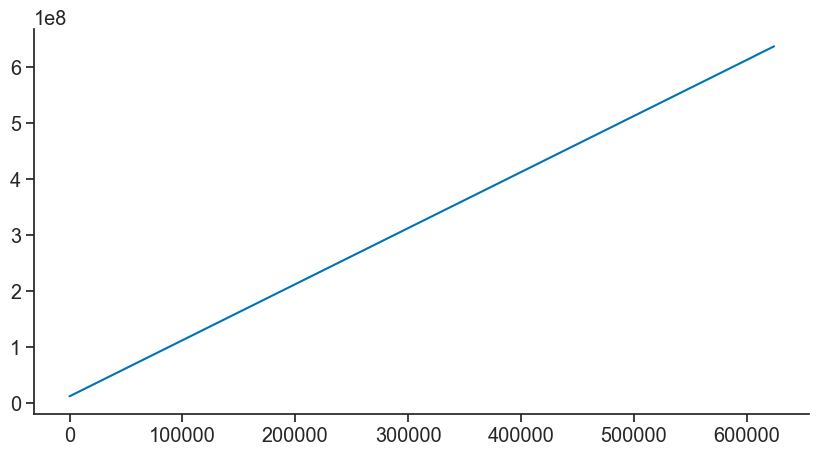

In [10]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(tsync_time)

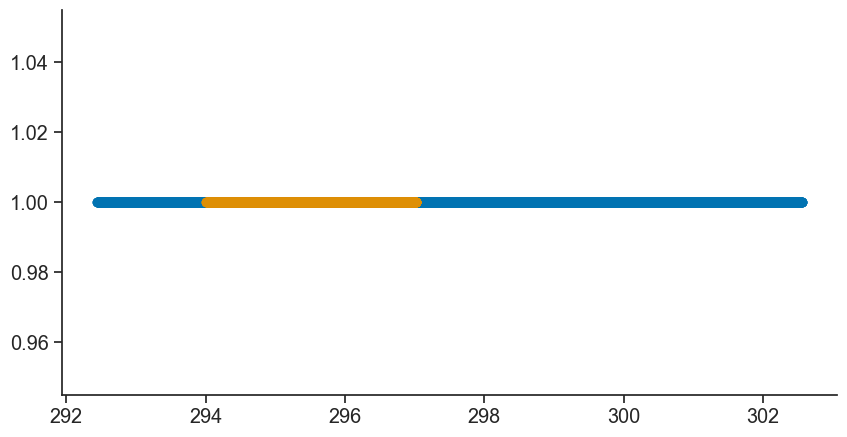

In [12]:
halloween = tsync_data['Halloween Environment']
halloween = nap.Tsd(tsync_time, halloween, time_units='us')
halloween_epoch = halloween.threshold(0.5).time_support

nature = tsync_data['Nature Environment']
nature = nap.Tsd(tsync_time, nature, time_units='us')
nature_epoch = nature.threshold(0.5).time_support

reward = tsync_data['Valve Toggle']
reward = nap.Tsd(tsync_time, reward, time_units='us').threshold(0.5)
reward_epoch = reward.time_support

reward_zone = tsync_data['Reward Tile']
reward_zone = nap.Tsd(tsync_time, reward_zone, time_units='us').threshold(0.5)
reward_zone_epoch = reward_zone.time_support

(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(reward_zone.t, reward_zone.values, marker='o', label='reward_zone')
ax.plot(reward.t, reward.values, marker='o', label='reward')
#ax.set_xlim(distance.start, distance.end)

In [ ]:
for i in nature_epoch:
    print(i)

In [ ]:
nature_epoch

In [13]:
velocity = distance.derivative()
velocity = velocity.threshold(-600)
velocity_smoothed = velocity.smooth(std=0.3, windowsize=1)
vel_hist, bin_edges = np.histogram(velocity_smoothed.values, bins=20)



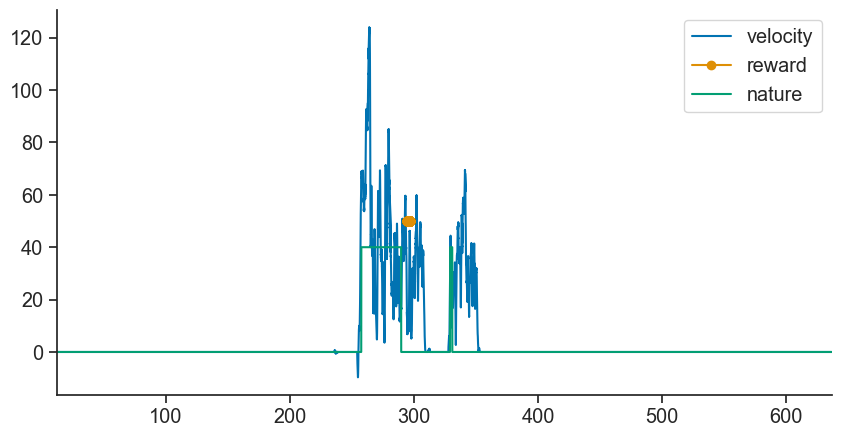

In [14]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(velocity_smoothed.t, velocity_smoothed.values, label='velocity')

#ax.plot(reward_zone.t, reward_zone.values*50, marker='o', label='reward_zone')
ax.plot(reward.t, reward.values*50, marker='o', label='reward')
ax.plot(nature.t, nature.values*40, label='nature')
ax.set_xlim(distance.start, distance.end)
ax.legend()
#ax.set_ylim(-10000, 10000)

In [15]:
vel_hist, bin_edges = np.histogram(velocity_smoothed.values, bins=20)

<BarContainer object of 20 artists>

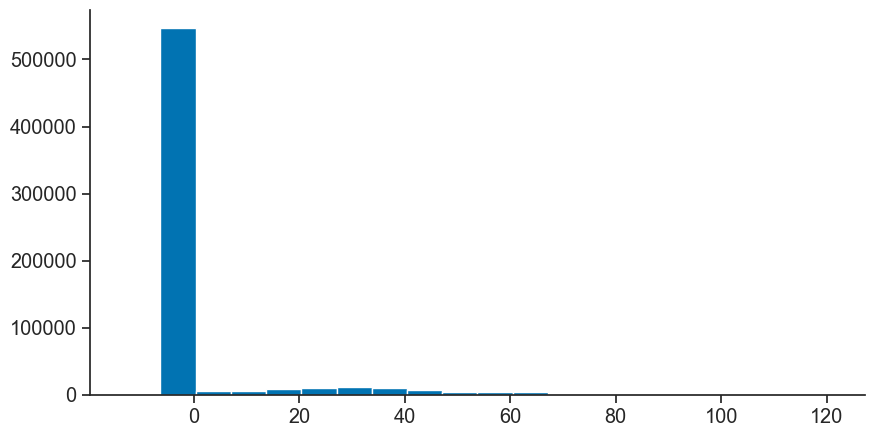

In [16]:
(fig, ax) = plt.subplots(figsize=(10, 5))

ax.bar(x=bin_edges[:-1], height=vel_hist, width=bin_edges[1]-bin_edges[0])

(array([0.00000e+00, 1.70000e+01, 2.60000e+01, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 8.74160e+04, 5.31048e+05, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 2.49100e+03, 3.34800e+03]),
 array([-600., -550., -500., -450., -400., -350., -300., -250., -200.,
        -150., -100.,  -50.,    0.,   50.,  100.,  150.,  200.,  250.,
         300.,  350.,  400.,  450.,  500.,  550.]),
 <BarContainer object of 23 artists>)

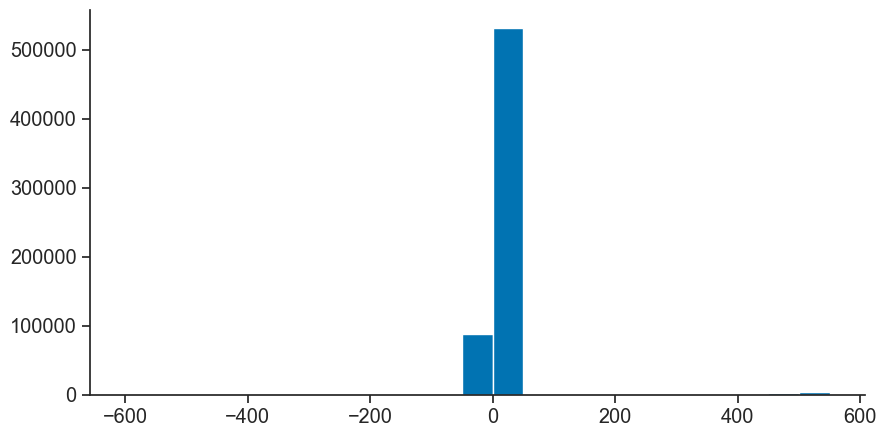

In [17]:
(fig, ax) = plt.subplots(figsize=(10, 5))


plt.hist(velocity, bins = np.arange(-600, 600, 50) )

In [18]:
path_2p = Path(s3d_results_folder)

f_file = path_2p / "F.npy"

In [19]:
cells_f = np.load(f_file, allow_pickle=True)

In [20]:
cells_f

array([[ 856.9276265 ,  782.60226841,  744.14947818, ...,  842.72827797,
         868.64101891,  918.6247989 ],
       [ 600.70937788,  482.95308536,  518.27911683, ...,  740.19263286,
         616.00336653,  542.35673873],
       [ 867.16137886,  662.35052515,  685.16575245, ...,  777.324884  ,
         651.70301868,  729.03523866],
       ...,
       [1003.45493577, 1752.73600208,  672.88276204, ...,  430.28690875,
         876.399709  ,  613.9572311 ],
       [1592.47691958, 1147.03572647, 1455.81812525, ..., 1113.22942371,
        1506.45089346,  546.94094632],
       [1592.42134826, 1118.72660792, 1621.95608213, ...,  474.22297353,
        1268.16032902, 1418.75332338]], shape=(1953, 6013))

In [21]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) > 0)[0]+1

(1375000.0, 1376118.0)

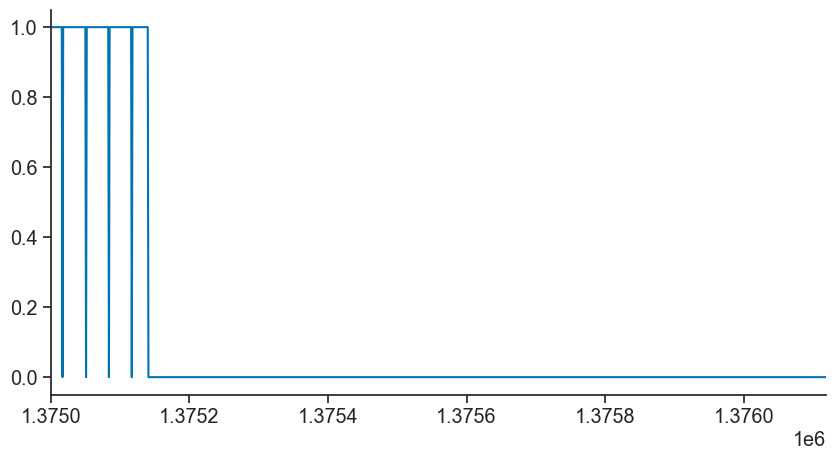

In [50]:
(fig, ax) = plt.subplots(figsize=(10, 5))

ax.plot(frame_clock)
ax.set_xlim(1375000, 1376118)

In [48]:
onsets[-1]

np.int64(1375118)

In [30]:
onsets[0]

np.int64(6979)

In [33]:
(609157-6979)/33.3333333

18065.34001806534

In [34]:
np.median(np.diff(onsets))

np.float64(33.0)

In [37]:
hist, bin_edges = np.histogram(np.diff(onsets), np.arange(30, 38))

In [38]:
hist

array([    0,     0,     0, 10938,  7094,     0,     0])

In [39]:
bin_edges

array([30, 31, 32, 33, 34, 35, 36, 37])

In [40]:
np.mean(np.diff(onsets))

np.float64(33.39126095153599)

In [22]:
barcode = tsync_data['Barcode (Scanner)']

In [23]:
barcode

array([0, 0, 0, ..., 0, 0, 0], shape=(624348,), dtype=uint16)